# Interpretabilidad del Modelo con SHAP — Predicción de Dengue## Universidad de El Salvador — IngenieríaEste notebook aplica **SHAP (SHapley Additive exPlanations)** al mejor modelo obtenido(Random Forest con transformación logarítmica) para interpretar cómo cada variableinfluye en las predicciones.**¿Qué es SHAP?**SHAP es una técnica basada en teoría de juegos que asigna a cada variable una "contribución"a cada predicción individual. A diferencia de la importancia nativa del modelo (que solo diceQUÉ variables importan), SHAP explica CÓMO afectan: si empujan la predicción hacia arriba ohacia abajo, y con qué magnitud.**Qué genera este notebook:**1. Summary plot — visión global de qué variables importan y en qué dirección2. Bar plot — ranking de importancia por magnitud SHAP3. Dependence plots — cómo una variable específica afecta la predicción4. Waterfall — explicación de una predicción individual

## 1. Instalación de SHAP e importación

In [12]:
!pip install shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.ensemble import RandomForestRegressor

plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
print('SHAP versión:', shap.__version__)

SHAP versión: 0.52.0


## 2. Carga de datos y reconstrucción del mejor modelo

In [13]:
BASE = 'https://raw.githubusercontent.com/Melvillalta1/DengueSV/refs/heads/main/'

train = pd.read_csv(BASE + 'dataset_train.csv')
val   = pd.read_csv(BASE + 'dataset_val.csv')
test  = pd.read_csv(BASE + 'dataset_test.csv')
deptos = pd.read_csv(BASE + 'tabla%20departamentos.csv')

# Integrar id de departamento
for d in [train, val, test]:
    pass
train = train.merge(deptos, on='departamento', how='left')
val   = val.merge(deptos, on='departamento', how='left')
test  = test.merge(deptos, on='departamento', how='left')

print(f'Train: {train.shape} | Test: {test.shape}')

Train: (4233, 46) | Test: (312, 46)


In [14]:
# Selección de variables (igual que en el entrenamiento)
OBJETIVO = 'casos_total'
excluir = ['casos_confirmados', 'casos_probables', 'casos_total',
           'anio_epi', 'departamento']
predictoras = [c for c in train.columns if c not in excluir]

# Preparar datos
X_train = train[predictoras].copy()
y_train_real = train[OBJETIVO].copy()

# Limpiar nulos de rezagos
mask = X_train.notna().all(axis=1)
X_train, y_train_real = X_train[mask], y_train_real[mask]

X_test = test[predictoras].fillna(0).copy()
y_test_real = test[OBJETIVO].copy()

# Transformación logarítmica del objetivo
y_train_log = np.log1p(y_train_real)

print(f'Predictoras: {len(predictoras)}')
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

Predictoras: 41
X_train: (4177, 41) | X_test: (312, 41)


In [15]:
# Reconstruir el mejor modelo: Random Forest con objetivo log
modelo_rf = RandomForestRegressor(
    n_estimators=300, max_depth=12, min_samples_leaf=3,
    random_state=42, n_jobs=-1
)
modelo_rf.fit(X_train, y_train_log)
print('✓ Modelo Random Forest (log) entrenado')

✓ Modelo Random Forest (log) entrenado


## 3. Cálculo de valores SHAPUsamos `TreeExplainer`, optimizado para modelos de árboles como Random Forest.Calculamos los valores SHAP sobre el conjunto de prueba.

In [16]:
# TreeExplainer es rápido y exacto para modelos de árboles
explainer = shap.TreeExplainer(modelo_rf)

# Calcular valores SHAP sobre el conjunto de prueba
shap_values = explainer.shap_values(X_test)

print(f'Valores SHAP calculados: {shap_values.shape}')
print('(filas = observaciones de test, columnas = variables)')

Valores SHAP calculados: (312, 41)
(filas = observaciones de test, columnas = variables)


## 4. Summary Plot — Visión globalEste es el gráfico SHAP más importante. Cada punto es una observación. La posición horizontalmuestra si esa variable empujó la predicción hacia arriba (derecha) o abajo (izquierda). Elcolor indica si el valor de la variable era alto (rojo) o bajo (azul).**Cómo leerlo:** si los puntos rojos están a la derecha, significa que valores ALTOS de esavariable AUMENTAN la predicción de casos.

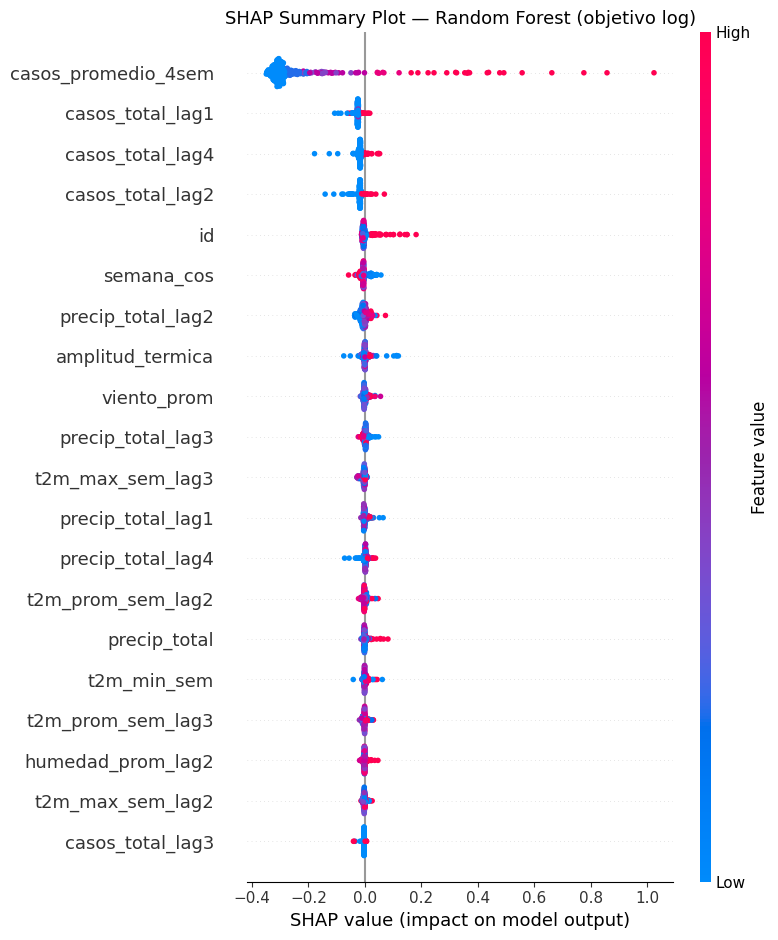

In [17]:
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot — Random Forest (objetivo log)', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretación esperada:** Las variables de rezagos de casos (casos_promedio_4sem,casos_total_lag1, etc.) deberían aparecer arriba, y sus puntos rojos (valores altos) deberíanestar a la derecha — confirmando que más casos recientes predicen más casos futuros.

## 5. Bar Plot — Ranking de importancia SHAP

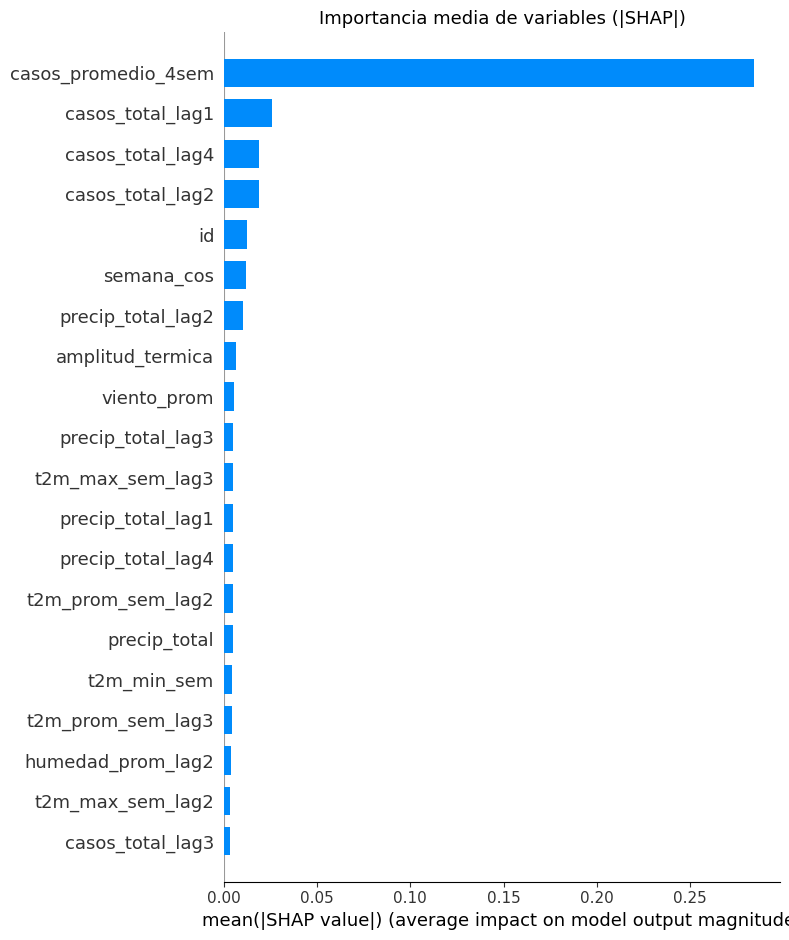

In [18]:
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Importancia media de variables (|SHAP|)', fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
# Tabla numérica de importancia SHAP
importancia_shap = pd.DataFrame({
    'variable': predictoras,
    'shap_medio_abs': np.abs(shap_values).mean(axis=0)
}).sort_values('shap_medio_abs', ascending=False)

print('Top 15 variables por importancia SHAP:')
print(importancia_shap.head(15).to_string(index=False))

Top 15 variables por importancia SHAP:
           variable  shap_medio_abs
casos_promedio_4sem        0.284164
   casos_total_lag1        0.025597
   casos_total_lag4        0.018897
   casos_total_lag2        0.018785
                 id        0.012423
         semana_cos        0.011640
  precip_total_lag2        0.010335
   amplitud_termica        0.006625
        viento_prom        0.005296
  precip_total_lag3        0.004862
   t2m_max_sem_lag3        0.004852
  precip_total_lag1        0.004844
  precip_total_lag4        0.004791
  t2m_prom_sem_lag2        0.004635
       precip_total        0.004621


## 6. Dependence Plots — Cómo afecta cada variableEstos gráficos muestran la relación entre el valor de una variable y su impacto SHAP.Analizamos las 2 variables más importantes.

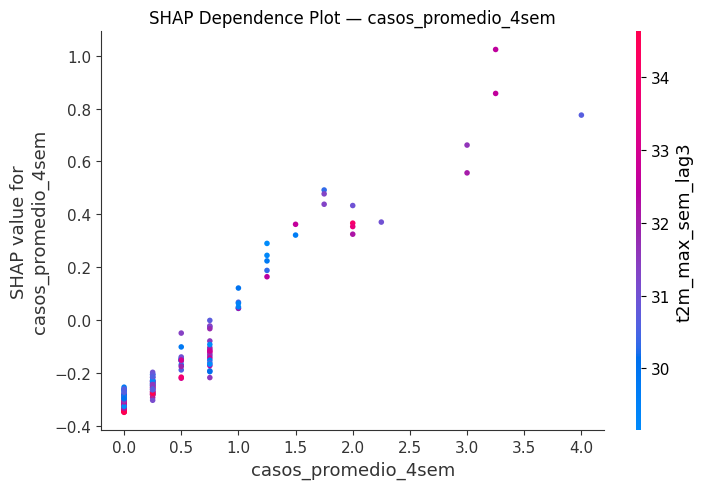

Este gráfico muestra cómo distintos valores de casos_promedio_4sem afectan la predicción.


In [20]:
# Dependence plot de la variable más importante
var_top = importancia_shap.iloc[0]['variable']
shap.dependence_plot(var_top, shap_values, X_test, show=False)
plt.title(f'SHAP Dependence Plot — {var_top}', fontsize=12)
plt.tight_layout()
plt.show()
print(f'Este gráfico muestra cómo distintos valores de {var_top} afectan la predicción.')

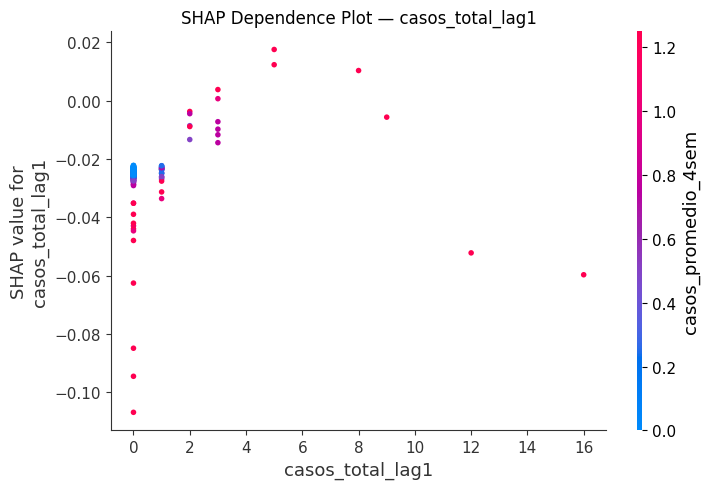

In [21]:
# Dependence plot de la segunda variable más importante
var_top2 = importancia_shap.iloc[1]['variable']
shap.dependence_plot(var_top2, shap_values, X_test, show=False)
plt.title(f'SHAP Dependence Plot — {var_top2}', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Waterfall — Explicación de una predicción individualSHAP también explica predicciones individuales. Este gráfico muestra cómo cada variablecontribuyó a alejar la predicción del valor base para UNA observación específica.Elegimos una semana-departamento con casos para que sea ilustrativa.

Observación elegida:
  Departamento: Ahuachapan
  Semana: 38 de 2023
  Casos reales: 1
  Predicción (casos): 0.05


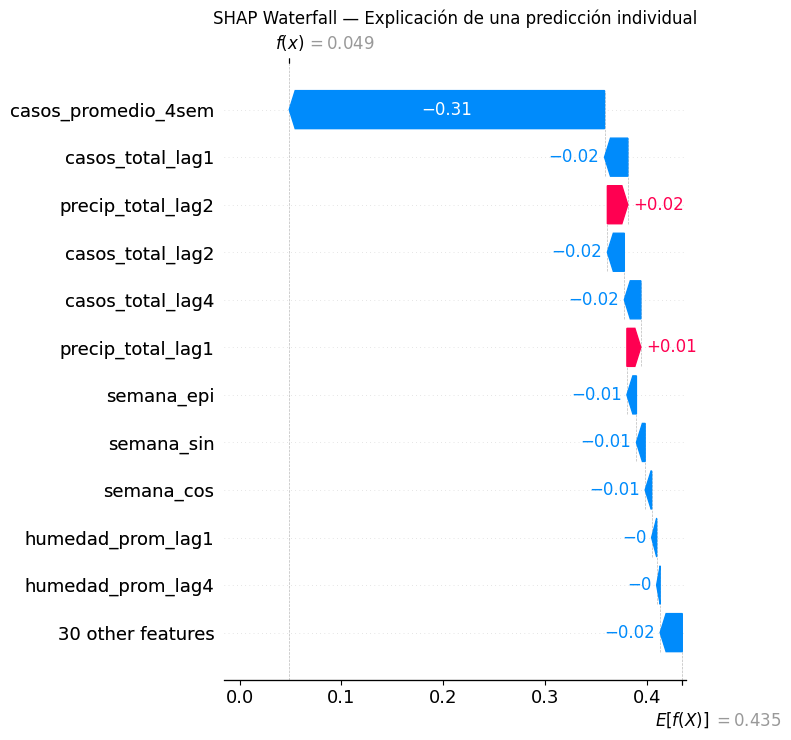

In [23]:
# Buscar una observación de test con casos > 0 para que sea interesante
idx_con_casos = np.where(y_test_real.values > 0)[0]
if len(idx_con_casos) > 0:
    idx = idx_con_casos[0]
else:
    idx = 0

# Info de la observación elegida
fila = test.iloc[idx]
print(f'Observación elegida:')
print(f'  Departamento: {fila["departamento"]}')
print(f'  Semana: {fila["semana_epi"]} de {fila["anio_epi"]}')
print(f'  Casos reales: {fila["casos_total"]}')
pred_log = modelo_rf.predict(X_test.iloc[[idx]])[0]
print(f'  Predicción (casos): {np.expm1(pred_log):.2f}')

# ── Corrección: extraer el valor escalar de expected_value ──
valor_base = explainer.expected_value
if isinstance(valor_base, (list, np.ndarray)):
    valor_base = valor_base[0]

# Waterfall plot
shap.plots._waterfall.waterfall_legacy(
    valor_base,
    shap_values[idx],
    feature_names=predictoras,
    max_display=12,
    show=False
)
plt.title('SHAP Waterfall — Explicación de una predicción individual', fontsize=12)
plt.tight_layout()
plt.show()

**Nota:** El gráfico está en escala logarítmica (porque el modelo fue entrenado en log).Muestra cómo cada variable suma o resta al valor base para llegar a la predicción final deesta observación específica.

## 8. Conclusiones de la interpretabilidad SHAPDocumenta aquí los hallazgos:### Hallazgos globales (Summary y Bar plots)- **Variables más influyentes según SHAP:** _(completar — deberían ser los rezagos de casos)_- **¿Coincide con la importancia nativa del Random Forest?:** _(sí/no, comentar)_- **Dirección del efecto:** _(¿valores altos de casos previos aumentan la predicción?)_### Hallazgos de dependencia- _(¿Cómo afecta la variable más importante? ¿Relación lineal, con saturación, etc.?)_### Valor para el proyectoSHAP confirma de forma rigurosa (no solo con la importancia nativa) que el modelo basa suspredicciones principalmente en el historial reciente de casos, lo cual es coherente con ladinámica de transmisión del dengue (autocorrelación epidemiológica). Esto da confianza enque el modelo aprendió relaciones con sentido epidemiológico y no artefactos espurios.### Interpretación para el MINSALLa interpretabilidad SHAP permite explicar a las autoridades de salud POR QUÉ el modelopredice un aumento de casos en cierta semana y departamento, aumentando la confianza yutilidad de la herramienta para la toma de decisiones.